
# Informe de análisis descriptivo multivariado  
**Tablas analizadas:** T1.4 a T1.9

Este notebook fue construido para que **todo se muestre en pantalla al ejecutar**: tablas resumen, comentarios e
inspecciones gráficas.  
Se usan funciones **sencillas, reutilizables y separadas por conjunto de datos**, con conversión explícita de variables numéricas.

**Objetivo por tabla**
1. Obtener medidas de posición y dispersión.
2. Aplicar técnicas gráficas multivariadas para detectar patrones, grupos y posibles outliers.
3. Presentar una salida tipo informe, breve y lista para entregar.

> Nota: en algunas tablas los nombres originales de las variables no vienen incluidos en los archivos de texto.
> En esos casos se usan nombres genéricos (`Var1`, `Var2`, etc.) para no introducir supuestos no verificados.


In [3]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from pandas.plotting import parallel_coordinates, andrews_curves
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


In [4]:

# =========================
# Utilidades generales
# =========================

def leer_tabla(path, columnas=None, sep=None, decimal=","):
    """
    Lee archivos .txt separados por tabulaciones o espacios.
    Convierte automáticamente decimales con coma cuando corresponde.
    """
    if sep is None:
        with open(path, "r", encoding="utf-8") as f:
            primera_linea = f.readline()
        sep = "\t" if "\t" in primera_linea else r"\s+"

    with open(path, "r", encoding="utf-8") as f:
        primera_linea = f.readline().lower()

    header = 0 if columnas is None and sep == "\t" and "company" in primera_linea else None

    df = pd.read_csv(
        path,
        sep=sep,
        engine="python",
        header=header,
        decimal=decimal
    )

    if columnas is not None:
        df.columns = columnas

    return df


def convertir_numericas(df, excluir=None):
    """
    Convierte columnas no excluidas a numéricas.
    Maneja comas decimales, strings con espacios y valores faltantes.
    """
    if excluir is None:
        excluir = []

    out = df.copy()

    for col in out.columns:
        if col in excluir:
            continue

        if out[col].dtype == "O":
            out[col] = (
                out[col]
                .astype(str)
                .str.strip()
                .str.replace(",", ".", regex=False)
            )

        try:
            out[col] = pd.to_numeric(out[col])
        except:
            pass

    return out


def columnas_numericas(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()


def resumen_descriptivo(df):
    """
    Tabla compacta con medidas de posición y dispersión.
    """
    num = df[columnas_numericas(df)]
    resumen = pd.DataFrame({
        "Media": num.mean(),
        "Mediana": num.median(),
        "Desv.Std": num.std(),
        "CV_%": (num.std() / num.mean().replace(0, np.nan)) * 100,
        "Mín": num.min(),
        "Q1": num.quantile(0.25),
        "Q3": num.quantile(0.75),
        "Máx": num.max(),
        "IQR": num.quantile(0.75) - num.quantile(0.25)
    })
    return resumen.round(3)


def detectar_outliers_iqr(df):
    """
    Devuelve:
    - matriz booleana de outliers por IQR
    - conteo de outliers por fila
    """
    num = df[columnas_numericas(df)]
    q1 = num.quantile(0.25)
    q3 = num.quantile(0.75)
    iqr = q3 - q1

    mascara = (num < (q1 - 1.5 * iqr)) | (num > (q3 + 1.5 * iqr))
    conteo = mascara.sum(axis=1)
    return mascara, conteo


def correlaciones_fuertes(df, top_n=5):
    num = df[columnas_numericas(df)]
    corr = num.corr()

    pares = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pares.append((cols[i], cols[j], corr.iloc[i, j]))

    pares = sorted(pares, key=lambda x: abs(x[2]), reverse=True)
    return pares[:top_n], corr


def pca_2d(df):
    num = df[columnas_numericas(df)]
    z = StandardScaler().fit_transform(num)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(z)

    coords_df = pd.DataFrame(coords, columns=["PC1", "PC2"], index=df.index)
    return coords_df, pca.explained_variance_ratio_


def comentar_dataset(nombre, df, etiqueta_grupo=None):
    """
    Genera un comentario breve, automático y legible.
    """
    resumen = resumen_descriptivo(df)
    top_corr, _ = correlaciones_fuertes(df, top_n=3)
    _, conteo_outliers = detectar_outliers_iqr(df)

    vars_mas_variables = resumen["CV_%"].sort_values(ascending=False).head(2).index.tolist()
    vars_mas_estables = resumen["CV_%"].sort_values().head(2).index.tolist()

    texto = []
    texto.append(f"**Comentario breve – {nombre}.**")
    texto.append(
        f"Las variables con mayor heterogeneidad son **{', '.join(vars_mas_variables)}**, "
        f"mientras que las más estables son **{', '.join(vars_mas_estables)}**."
    )

    if top_corr:
        corr_txt = "; ".join([f"**{a}–{b}** ({c:.2f})" for a, b, c in top_corr])
        texto.append(f"Las asociaciones lineales más fuertes son: {corr_txt}.")

    n_out = int((conteo_outliers > 0).sum())
    if n_out > 0:
        texto.append(
            f"Se detectan **{n_out} observaciones con al menos un outlier** según el criterio IQR, "
            f"lo que sugiere revisar casos extremos o subgrupos particulares."
        )
    else:
        texto.append("No se observan outliers notorios bajo el criterio IQR.")

    if etiqueta_grupo is not None and etiqueta_grupo in df.columns:
        distrib = df[etiqueta_grupo].value_counts().to_dict()
        texto.append(f"La variable de grupo presenta la distribución: **{distrib}**.")

    display(Markdown(" ".join(texto)))


def graficar_resumen_base(df, titulo, grupo=None, etiquetas=None):
    """
    Heatmap de correlación + boxplots estandarizados + PCA 2D
    """
    num_cols = columnas_numericas(df)
    num = df[num_cols]

    _, corr = correlaciones_fuertes(df, top_n=3)
    plt.figure(figsize=(7, 5))
    plt.imshow(corr, cmap="coolwarm", aspect="auto")
    plt.colorbar(label="Correlación")
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title(f"{titulo} - Matriz de correlación")
    plt.tight_layout()
    plt.show()

    z = pd.DataFrame(StandardScaler().fit_transform(num), columns=num_cols, index=df.index)
    plt.figure(figsize=(10, 5))
    plt.boxplot([z[c].dropna() for c in z.columns], tick_labels=z.columns, vert=True)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{titulo} - Boxplots estandarizados")
    plt.tight_layout()
    plt.show()

    coords, var_exp = pca_2d(df)
    plt.figure(figsize=(8, 6))
    if grupo and grupo in df.columns:
        for g in sorted(df[grupo].astype(str).unique()):
            mask = df[grupo].astype(str) == str(g)
            plt.scatter(coords.loc[mask, "PC1"], coords.loc[mask, "PC2"], label=f"{grupo}={g}", alpha=0.8)
        plt.legend()
    else:
        plt.scatter(coords["PC1"], coords["PC2"], alpha=0.8)

    if etiquetas is not None:
        for i, txt in etiquetas.items():
            plt.annotate(str(txt), (coords.loc[i, "PC1"], coords.loc[i, "PC2"]), fontsize=8, alpha=0.8)

    plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}% var.)")
    plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}% var.)")
    plt.title(f"{titulo} - PCA")
    plt.tight_layout()
    plt.show()


def graficar_parallel(df, titulo, grupo_col=None, max_filas=60):
    """
    Gráfico de coordenadas paralelas sobre datos estandarizados.
    """
    num_cols = columnas_numericas(df)
    temp = df.copy()

    if len(temp) > max_filas:
        temp = temp.iloc[:max_filas].copy()

    z = pd.DataFrame(StandardScaler().fit_transform(temp[num_cols]), columns=num_cols, index=temp.index)
    if grupo_col and grupo_col in temp.columns:
        z["Grupo"] = temp[grupo_col].astype(str).values
    else:
        z["Grupo"] = "Obs"

    plt.figure(figsize=(11, 6))
    parallel_coordinates(z, "Grupo", colormap="tab10", alpha=0.4)
    plt.title(f"{titulo} - Coordenadas paralelas")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def graficar_andrews(df, titulo, grupo_col=None, max_filas=60):
    """
    Curvas de Andrews, útil para comparar perfiles multivariados.
    """
    num_cols = columnas_numericas(df)
    temp = df.copy()

    if len(temp) > max_filas:
        temp = temp.iloc[:max_filas].copy()

    z = pd.DataFrame(StandardScaler().fit_transform(temp[num_cols]), columns=num_cols, index=temp.index)
    if grupo_col and grupo_col in temp.columns:
        z["Grupo"] = temp[grupo_col].astype(str).values
    else:
        z["Grupo"] = "Obs"

    plt.figure(figsize=(11, 6))
    andrews_curves(z, "Grupo", alpha=0.4)
    plt.title(f"{titulo} - Curvas de Andrews")
    plt.tight_layout()
    plt.show()


In [ ]:

ARCHIVOS = {
    "T1_4": "tarea_1/T1.4.txt",
    "T1_5": "tarea_1/T1.5.txt",
    "T1_6": "tarea_1/T1.6.txt",
    "T1_7": "tarea_1/T1.7.txt",
    "T1_8": "tarea_1/T1.8.txt",
    "T1_9": "tarea_1/T1.9.txt",
}


In [5]:

# =========================
# Funciones por tabla
# =========================

def analizar_tabla_14():
    display(Markdown("## Tabla 1.4 – The World's 10 Largest Companies"))
    df = leer_tabla(ARCHIVOS["T1_4"], sep="\t", decimal=",")
    df = convertir_numericas(df, excluir=["company"])
    df = df.rename(columns={"company": "Empresa", "sales": "Ventas", "profits": "Utilidades", "assets": "Activos"})

    display(Markdown("### Vista previa"))
    display(df)

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    plt.figure(figsize=(8, 6))
    sizes = (df["Activos"] / df["Activos"].max()) * 2500 + 100
    plt.scatter(df["Ventas"], df["Utilidades"], s=sizes, alpha=0.6)
    for _, row in df.iterrows():
        plt.annotate(row["Empresa"].replace("_", " "), (row["Ventas"], row["Utilidades"]), fontsize=8)
    plt.xlabel("Ventas")
    plt.ylabel("Utilidades")
    plt.title("Tabla 1.4 - Ventas vs utilidades (tamaño = activos)")
    plt.tight_layout()
    plt.show()

    graficar_resumen_base(df, "Tabla 1.4", etiquetas=df["Empresa"].to_dict())
    graficar_parallel(df, "Tabla 1.4")

    comentar_dataset("Tabla 1.4", df)

    display(Markdown(
        "**Interpretación.** Este conjunto muestra escalas corporativas muy distintas: las firmas petroleras "
        "tienden a concentrarse en ventas altas, mientras que los grandes grupos financieros destacan por activos muy elevados. "
        "El gráfico de burbujas y el PCA permiten ver que las empresas no son homogéneas y que los extremos responden a modelos "
        "de negocio diferentes."
    ))


def analizar_tabla_15():
    display(Markdown("## Tabla 1.5 – Air-Pollution Data"))
    columnas = [f"Var{i}" for i in range(1, 8)]
    df = leer_tabla(ARCHIVOS["T1_5"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)

    display(Markdown("### Vista previa"))
    display(df.head())

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    graficar_resumen_base(df, "Tabla 1.5")
    graficar_parallel(df, "Tabla 1.5")
    graficar_andrews(df, "Tabla 1.5")

    comentar_dataset("Tabla 1.5", df)

    display(Markdown(
        "**Interpretación.** Al no contar con nombres originales de variables en el archivo, el análisis se centra en la estructura multivariada. "
        "Las gráficas sugieren diferencias claras en dispersión entre variables y permiten detectar observaciones con perfiles de contaminación "
        "relativamente extremos. La combinación de correlaciones, boxplots y representaciones funcionales ayuda a ubicar patrones no triviales."
    ))


def analizar_tabla_16():
    display(Markdown("## Tabla 1.6 – Multiple-Sclerosis Data"))
    columnas = ["Edad", "Var1", "Var2", "Var3", "Var4", "Grupo"]
    df = leer_tabla(ARCHIVOS["T1_6"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)

    display(Markdown("### Vista previa"))
    display(df.head())

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    vars_plot = ["Edad", "Var1", "Var2", "Var3", "Var4"]
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()

    for i, col in enumerate(vars_plot):
        datos = [df.loc[df["Grupo"] == g, col].dropna() for g in sorted(df["Grupo"].unique())]
        axes[i].boxplot(datos, tick_labels=[f"G{g}" for g in sorted(df["Grupo"].unique())])
        axes[i].set_title(col)

    axes[-1].axis("off")
    fig.suptitle("Tabla 1.6 - Boxplots por grupo")
    plt.tight_layout()
    plt.show()

    graficar_resumen_base(df, "Tabla 1.6", grupo="Grupo")
    graficar_parallel(df, "Tabla 1.6", grupo_col="Grupo")

    comentar_dataset("Tabla 1.6", df, etiqueta_grupo="Grupo")

    display(Markdown(
        "**Interpretación.** La presencia de una variable de grupo binaria hace especialmente útil comparar perfiles clínicos entre ambos conjuntos. "
        "Los boxplots por grupo y el PCA permiten revisar si hay separación parcial entre clases, mientras que los outliers pueden señalar pacientes "
        "con comportamiento atípico o mayor severidad en alguna medición."
    ))


def analizar_tabla_17():
    display(Markdown("## Tabla 1.7 – Radiotherapy Data"))
    columnas = ["Var1", "Var2", "Var3", "Var4", "Var5", "Clase"]
    df = leer_tabla(ARCHIVOS["T1_7"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)

    display(Markdown("### Vista previa"))
    display(df.head())

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    medias = df.groupby("Clase")[["Var1", "Var2", "Var3", "Var4", "Var5"]].mean()
    plt.figure(figsize=(9, 6))
    for clase, fila in medias.iterrows():
        plt.plot(medias.columns, fila.values, marker="o", label=f"Clase {clase}")
    plt.title("Tabla 1.7 - Perfil promedio por clase")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    graficar_resumen_base(df, "Tabla 1.7", grupo="Clase")
    graficar_andrews(df, "Tabla 1.7", grupo_col="Clase")

    comentar_dataset("Tabla 1.7", df, etiqueta_grupo="Clase")

    display(Markdown(
        "**Interpretación.** Este conjunto tiene una estructura naturalmente orientada a clasificación. "
        "El perfil promedio por clase resume diferencias sistemáticas entre grupos, mientras que el PCA y las curvas de Andrews "
        "permiten evaluar solapamientos, separación relativa y posibles casos ambiguos."
    ))


def analizar_tabla_18():
    display(Markdown("## Tabla 1.8 – Mineral Content in Bones"))
    columnas = [f"Mineral{i}" for i in range(1, 7)]
    df = leer_tabla(ARCHIVOS["T1_8"], columnas=columnas, sep=r"\s+")
    df = convertir_numericas(df)

    display(Markdown("### Vista previa"))
    display(df.head())

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    plt.figure(figsize=(8, 6))
    plt.scatter(df["Mineral1"], df["Mineral2"], alpha=0.8)
    for i in df.index[:5]:
        plt.annotate(str(i), (df.loc[i, "Mineral1"], df.loc[i, "Mineral2"]), fontsize=8)
    plt.xlabel("Mineral1")
    plt.ylabel("Mineral2")
    plt.title("Tabla 1.8 - Dispersión Mineral1 vs Mineral2")
    plt.tight_layout()
    plt.show()

    graficar_resumen_base(df, "Tabla 1.8")
    graficar_parallel(df, "Tabla 1.8")

    comentar_dataset("Tabla 1.8", df)

    display(Markdown(
        "**Interpretación.** Las variables presentan una escala bastante homogénea, por lo que resulta útil comparar correlaciones y perfiles relativos "
        "más que magnitudes absolutas. Si aparecen correlaciones fuertes entre minerales, esto puede interpretarse como una co-variación en la composición ósea."
    ))


def analizar_tabla_19():
    display(Markdown("## Tabla 1.9 – National Track Records for Women"))
    columnas = ["Pais", "100m", "200m", "400m", "800m", "1500m", "3000m", "Maraton"]
    df = leer_tabla(ARCHIVOS["T1_9"], columnas=columnas, sep="\t")
    df = convertir_numericas(df, excluir=["Pais"])

    display(Markdown("### Vista previa"))
    display(df.head())

    display(Markdown("### Medidas descriptivas"))
    display(resumen_descriptivo(df))

    num_cols = columnas_numericas(df)
    z = pd.DataFrame(StandardScaler().fit_transform(df[num_cols]), columns=num_cols, index=df["Pais"])

    plt.figure(figsize=(11, 10))
    plt.imshow(z, cmap="coolwarm", aspect="auto")
    plt.colorbar(label="z-score")
    plt.yticks(range(len(z.index)), z.index)
    plt.xticks(range(len(z.columns)), z.columns, rotation=45, ha="right")
    plt.title("Tabla 1.9 - Rendimiento estandarizado por país")
    plt.tight_layout()
    plt.show()

    graficar_resumen_base(df, "Tabla 1.9", etiquetas=df["Pais"].to_dict())
    graficar_parallel(df, "Tabla 1.9")

    comentar_dataset("Tabla 1.9", df)

    display(Markdown(
        "**Interpretación.** Como todas las variables son marcas deportivas, valores menores indican mejores desempeños. "
        "La estandarización es clave para comparar pruebas cortas, medias y largas en un mismo plano. El heatmap y el PCA ayudan a reconocer "
        "países con perfiles equilibrados frente a otros especializados o relativamente débiles en ciertas distancias."
    ))


def ejecutar_todo():
    analizar_tabla_14()
    analizar_tabla_15()
    analizar_tabla_16()
    analizar_tabla_17()
    analizar_tabla_18()
    analizar_tabla_19()


## Tabla 1.4 – The World's 10 Largest Companies

### Vista previa

,Empresa,Ventas,Utilidades,Activos
0,citigroup,108.28,17.05,1484.10
1,General_Electric,152.36,16.59,750.33
2,American_Intl_Group,95.04,10.91,766.42
3,Bank_of_America,65.45,14.14,1110.46
4,HSBC_Group,62.97,9.52,1031.29
5,ExxonMobil,263.99,25.33,195.26
6,Royal_Dutch/Shell,265.19,18.54,193.83
7,BP,285.06,15.73,191.11
8,ING_Group,92.01,8.10,1175.16
9,Toyota_Motor,165.68,11.13,211.15


### Medidas descriptivas

,Media,Mediana,Desv.Std,CV_%,Mín,Q1,Q3,Máx,IQR
Ventas,155.603,130.320,86.466,55.569,62.97,92.768,239.413,285.06,146.645
Utilidades,14.704,14.935,5.118,34.804,8.10,10.965,16.935,25.33,5.970
Activos,710.911,758.375,486.882,68.487,191.11,199.232,1090.668,1484.10,891.435


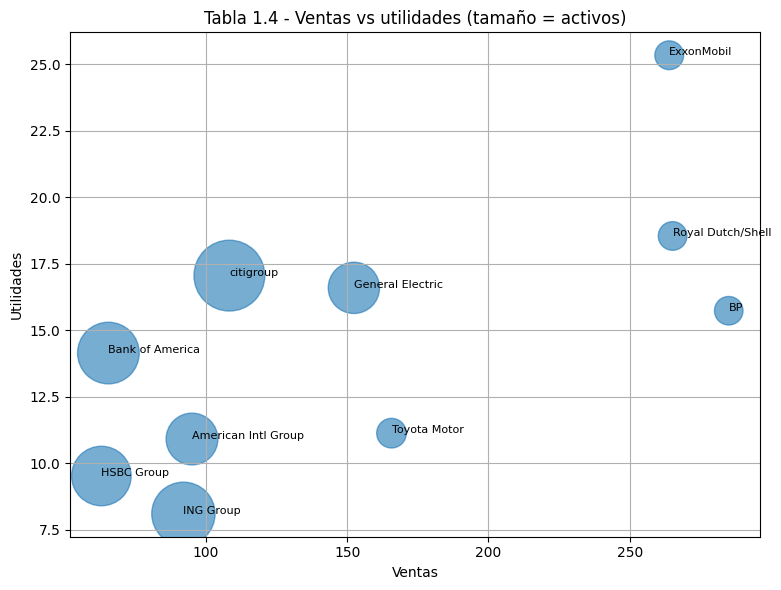

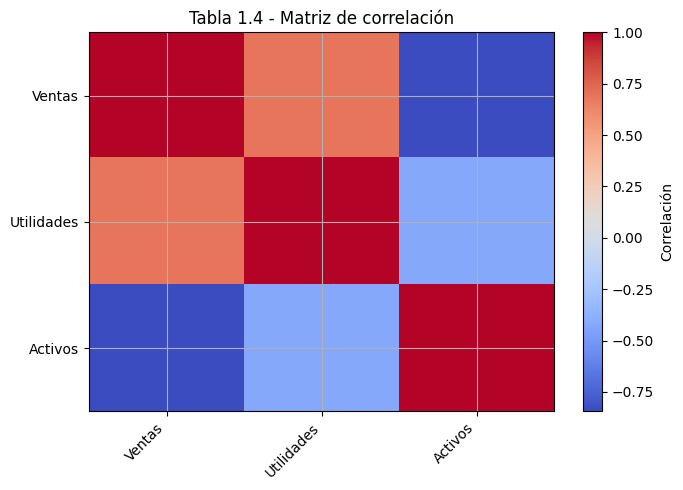

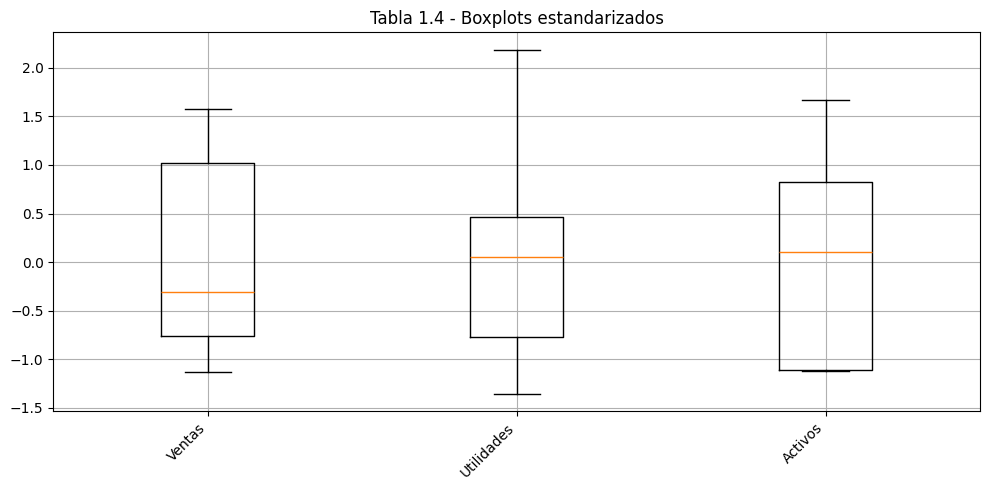

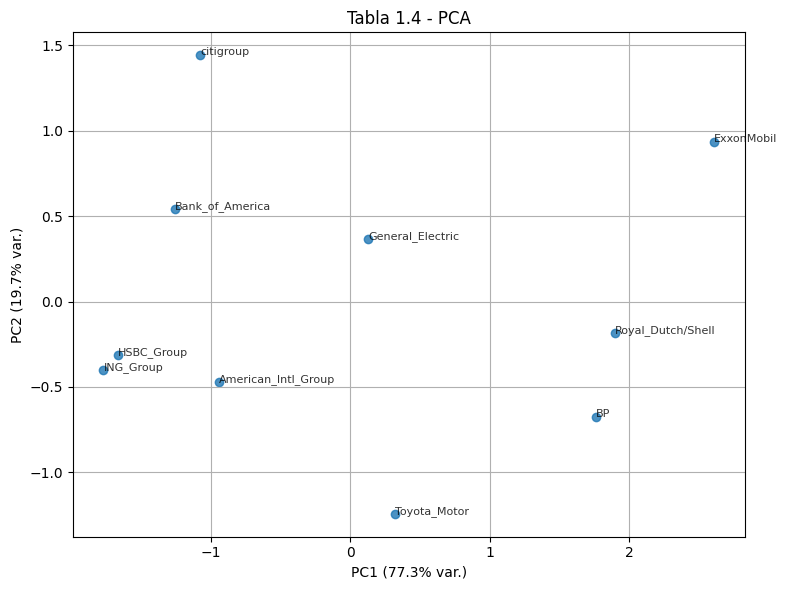

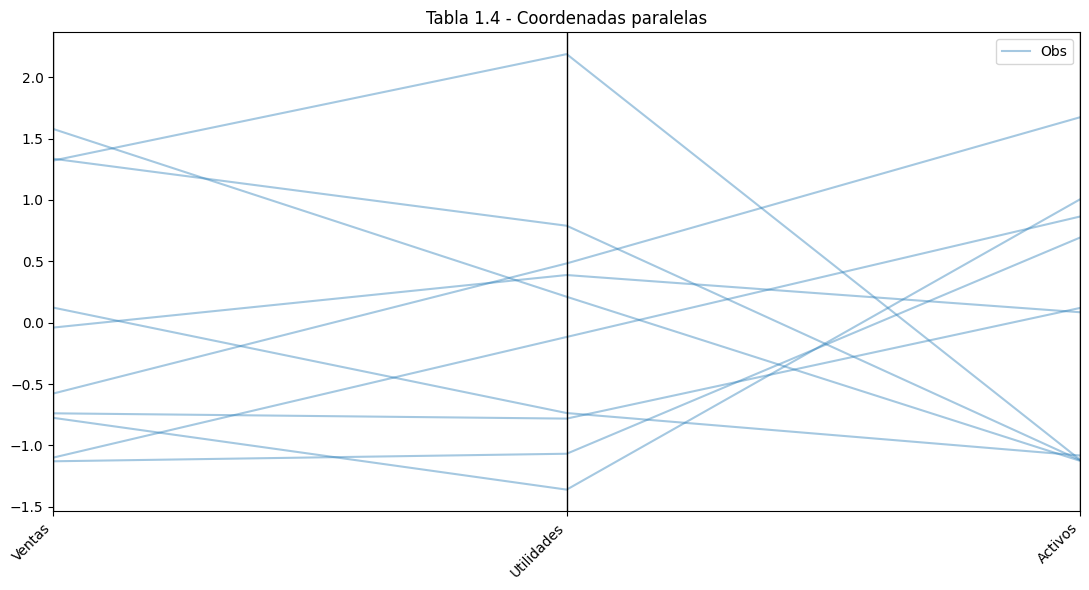

**Comentario breve – Tabla 1.4.** Las variables con mayor heterogeneidad son **Activos, Ventas**, mientras que las más estables son **Utilidades, Ventas**. Las asociaciones lineales más fuertes son: **Ventas–Activos** (-0.85); **Ventas–Utilidades** (0.69); **Utilidades–Activos** (-0.42). No se observan outliers notorios bajo el criterio IQR.

**Interpretación.** Este conjunto muestra escalas corporativas muy distintas: las firmas petroleras tienden a concentrarse en ventas altas, mientras que los grandes grupos financieros destacan por activos muy elevados. El gráfico de burbujas y el PCA permiten ver que las empresas no son homogéneas y que los extremos responden a modelos de negocio diferentes.

## Tabla 1.5 – Air-Pollution Data

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/T1.5.txt'

In [11]:

# Ejecuta todo el informe
ejecutar_todo()
